In [66]:
from opendrift.models.openoil import OpenOil
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt

print("Opendrift ready")

Opendrift ready


06:57:42 INFO    opendrift:569: OpenDriftSimulation initialised (version 1.14.10)
06:57:42 INFO    opendrift.models.openoil.adios.dirjs:86: Querying ADIOS database for oil: GENERIC BUNKER C
06:57:42 INFO    opendrift.models.openoil.openoil:1731: Using density 988.1 and viscosity 0.02169233387797564 of oiltype GENERIC BUNKER C
06:57:42 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
06:57:42 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
06:57:42 INFO    opendrift.models.basemodel.environment:230: 	x_sea_water_velocity: -0.300000
06:57:42 INFO    opendrift.models.basemodel.environment:230: 	y_sea_water_velocity: -0.100000
06:57:42 INFO    opendrift.models.basemodel.environment:230: 	x_wind: -5.000000
06:57:42 INFO    opendrift.models.basemodel.environment:230: 	y_wind: -2.000000
06:57:42 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_height: 0.0

Forward Simulation Complete


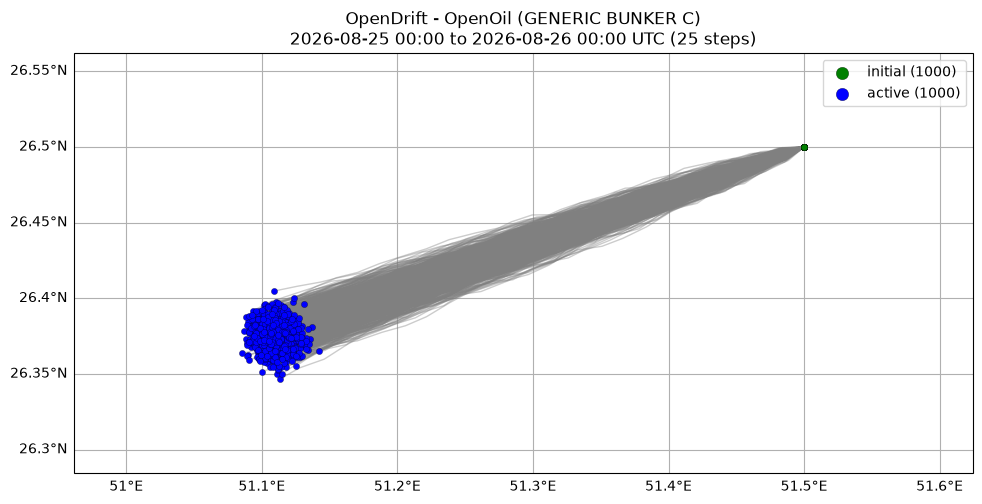

(<GeoAxes: title={'center': 'OpenDrift - OpenOil (GENERIC BUNKER C)\n2026-08-25 00:00 to 2026-08-26 00:00 UTC (25 steps)'}>,
 <Figure size 1100x514.523 with 1 Axes>)

In [67]:
# Forward simulation
o_forward = OpenOil(loglevel = 20)

o_forward.set_config('environment:fallback:x_wind', -5)
o_forward.set_config('environment:fallback:y_wind', -2)
o_forward.set_config('environment:fallback:x_sea_water_velocity', -0.3)
o_forward.set_config('environment:fallback:y_sea_water_velocity', -0.1)

detection_time = datetime(2026, 8, 25, 0, 0) # example: spill detecton time
detection_lon, detection_lat = 51.5, 26.5  # central Persian Gulf, open water

o_forward.seed_elements(lon=detection_lon, lat=detection_lat, number = 1000, time = detection_time, oil_type = "GENERIC BUNKER C")
o_forward.run(duration = timedelta(hours=24), time_step=3600)
print("Forward Simulation Complete")
o_forward.plot(fast = True)

06:57:49 INFO    opendrift:569: OpenDriftSimulation initialised (version 1.14.10)
06:57:49 INFO    opendrift.models.openoil.adios.dirjs:86: Querying ADIOS database for oil: GENERIC BUNKER C
06:57:49 INFO    opendrift.models.openoil.openoil:1731: Using density 988.1 and viscosity 0.02169233387797564 of oiltype GENERIC BUNKER C
06:57:49 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
06:57:49 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
06:57:49 INFO    opendrift.models.basemodel.environment:230: 	x_sea_water_velocity: 0.300000
06:57:49 INFO    opendrift.models.basemodel.environment:230: 	y_sea_water_velocity: 0.100000
06:57:49 INFO    opendrift.models.basemodel.environment:230: 	x_wind: 5.000000
06:57:49 INFO    opendrift.models.basemodel.environment:230: 	y_wind: 2.000000
06:57:49 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_height: 0.00000

Backward Simulation Complete


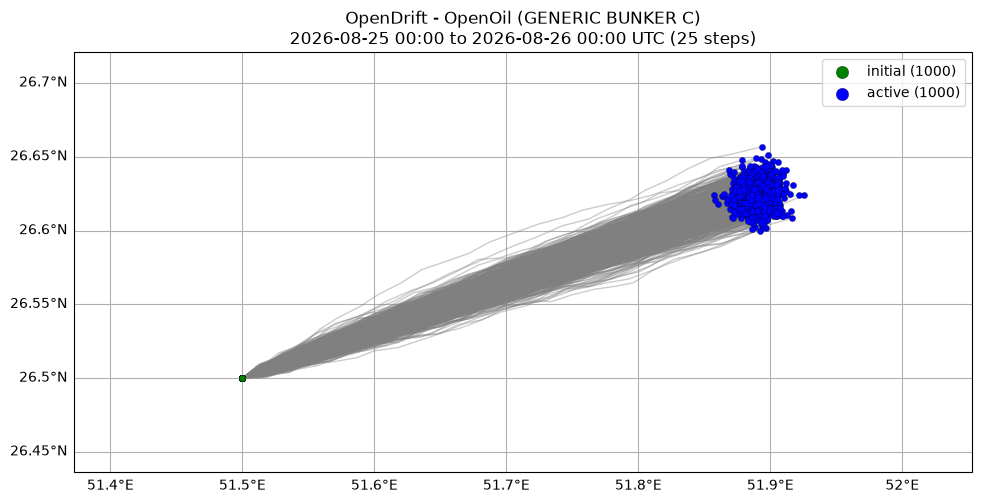

(<GeoAxes: title={'center': 'OpenDrift - OpenOil (GENERIC BUNKER C)\n2026-08-25 00:00 to 2026-08-26 00:00 UTC (25 steps)'}>,
 <Figure size 1100x513.976 with 1 Axes>)

In [68]:
# Backward Simulation
o_backward = OpenOil(loglevel=20)

o_backward.set_config('environment:fallback:x_wind', 5)
o_backward.set_config('environment:fallback:y_wind', 2)
o_backward.set_config('environment:fallback:x_sea_water_velocity', 0.3)
o_backward.set_config('environment:fallback:y_sea_water_velocity', 0.1)

o_backward.seed_elements(lon = detection_lon, lat = detection_lat, number = 1000, time=detection_time, oil_type='GENERIC BUNKER C')
o_backward.run(duration=timedelta(hours=24), time_step=3600)
print("Backward Simulation Complete")
o_backward.plot(fast=True)

In [69]:
# Final Particle Positions
final_lons = o_backward.result.lon.isel(time=-1).values
final_lats = o_backward.result.lat.isel(time=-1).values

estimated_origin_lon = np.nanmean(final_lons)
estimated_origin_lat = np.nanmean(final_lats)

print(f"Estimated origin: {estimated_origin_lon:.4f} E, {estimated_origin_lat:.4f} N")
print(f"Estimated origin time: {detection_time - timedelta(hours=24)}")

Estimated origin: 51.8901 E, 26.6250 N
Estimated origin time: 2026-08-24 00:00:00


In [74]:
import os
import copernicusmarine

output_file = "demo_currents_persian_gulf.nc"

if not os.path.exists(output_file):
    copernicusmarine.subset(
        dataset_id="cmems_mod_glo_phy_anfc_0.083deg_PT1H-m",
        variables=["uo", "vo"],
        minimum_longitude=48, maximum_longitude=57,
        minimum_latitude=24, maximum_latitude=30,
        minimum_depth=0,
        maximum_depth=1,
        start_datetime="2026-08-26T00:00:00",
        end_datetime="2026-08-29T00:00:00",
        output_filename=output_file,
    )
    print("Downloaded fresh data")
else:
    print("Using cached local file — skipping download")

INFO - 2026-09-02T06:58:44Z - Selected dataset version: "202406"
06:58:44 INFO    copernicusmarine:255: Selected dataset version: "202406"
INFO - 2026-09-02T06:58:44Z - Selected dataset part: "default"
06:58:44 INFO    copernicusmarine:277: Selected dataset part: "default"
WARNING - 2026-09-02T06:58:44Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 0.49402499198913574]
06:58:44 WARNING copernicusmarine:818: Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 0.49402499198913574]
 35%|██████████████████████████████████▎                                                                | [00:18<00:24]06:59:07 WARNING urllib3.connectionpool:327: Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
06:59:08 WARNING urllib3.connectionpool:327: Connection pool is full, discarding connection: s3.waw3-1.cloudferro

Downloaded fresh data


In [76]:
import requests
import math

OPENWEATHER_API_KEY = "API_KEY"

def get_current_wind(lat, lon):
    url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={OPENWEATHER_API_KEY}&units=metric"
    response = requests.get(url).json()

    if 'wind' not in response:
        raise ValueError(f"API call failed or unexpected response: {response}")

    speed = response['wind']['speed']
    deg = response['wind']['deg']
    u = -speed * math.sin(math.radians(deg))
    v = -speed * math.cos(math.radians(deg))
    return u, v

wind_u, wind_v = get_current_wind(51.5, 26.5)
print(f"Wind u/v: {wind_u:.2f}, {wind_v:.2f}")

Wind u/v: 5.20, 0.92


In [78]:
from opendrift.readers import reader_netCDF_CF_generic

reader_currents = reader_netCDF_CF_generic.Reader("demo_currents_persian_gulf.nc")
print(reader_currents)

06:59:57 INFO    opendrift.readers:67: Opening file with xr.open_dataset
06:59:57 INFO    opendrift.readers.reader_netCDF_CF_generic:307: Grid coordinates are detected, but proj4 string not given: assuming latlong
06:59:57 INFO    opendrift.readers.reader_netCDF_CF_generic:340: Detected dimensions: {'z': 'depth', 'y': 'latitude', 'x': 'longitude', 'time': 'time'}
06:59:57 INFO    opendrift.readers.basereader:178: Variable x_sea_water_velocity will be rotated from eastward_sea_water_velocity
06:59:57 INFO    opendrift.readers.basereader:178: Variable y_sea_water_velocity will be rotated from northward_sea_water_velocity


Reader: demo_currents_persian_gulf.nc
Reader type: opendrift.readers.reader_netCDF_CF_generic
Projection: 
  +proj=latlong
Coverage: [degrees]
  xmin: 48.000000   xmax: 57.000000   step: 0.0833435   numx: 108
  ymin: 24.000000   ymax: 30.000000   step: 0.0833359   numy: 72
  Corners (lon, lat):
    ( 48.00,  30.00)  ( 57.00,  30.00)
    ( 48.00,  24.00)  ( 57.00,  24.00)
Vertical levels [m]: 
  [-0.494025]
Available time range:
  start: 2026-08-26 00:00:00   end: 2026-08-29 00:00:00   step: 1:00:00
    73 times (0 missing)
Variables:
  eastward_sea_water_velocity
  northward_sea_water_velocity
  x_sea_water_velocity
  y_sea_water_velocity
  sea_water_speed - derived from ['x_sea_water_velocity', 'y_sea_water_velocity']



07:00:03 INFO    opendrift:569: OpenDriftSimulation initialised (version 1.14.10)
07:00:03 INFO    opendrift.models.openoil.adios.dirjs:86: Querying ADIOS database for oil: GENERIC BUNKER C
07:00:03 INFO    opendrift.models.openoil.openoil:1731: Using density 988.1 and viscosity 0.02169233387797564 of oiltype GENERIC BUNKER C
07:00:03 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
07:00:03 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
07:00:03 INFO    opendrift.models.basemodel.environment:230: 	x_wind: 5.199785
07:00:03 INFO    opendrift.models.basemodel.environment:230: 	y_wind: 0.916862
07:00:03 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_height: 0.000000
07:00:03 INFO    opendrift.models.basemodel.environment:230: 	upward_sea_water_velocity: 0.000000
07:00:03 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_signifi

Backward trace with real data complete


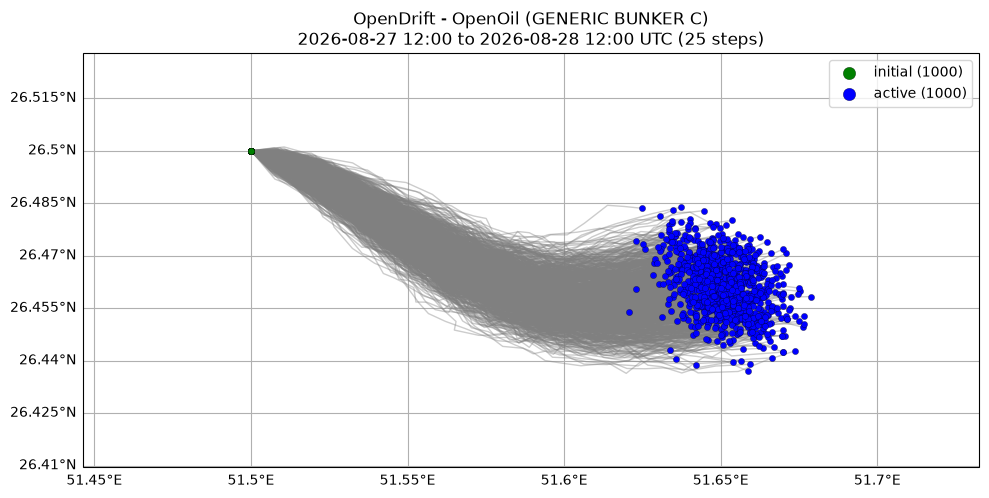

(<GeoAxes: title={'center': 'OpenDrift - OpenOil (GENERIC BUNKER C)\n2026-08-27 12:00 to 2026-08-28 12:00 UTC (25 steps)'}>,
 <Figure size 1100x508.31 with 1 Axes>)

In [79]:
detection_time = datetime(2026, 8, 27, 12, 0, 0)  # within your data's 08-26 to 08-29 range
detection_lon, detection_lat = 51.5, 26.5  # central Persian Gulf, open water


o_backward = OpenOil(loglevel=20)
o_backward.add_reader([reader_currents])
o_backward.set_config('environment:fallback:x_wind', wind_u)
o_backward.set_config('environment:fallback:y_wind', wind_v)

o_backward.seed_elements(lon=detection_lon, lat=detection_lat, number=1000, time=detection_time, oil_type='GENERIC BUNKER C')
o_backward.run(duration=timedelta(hours=24), time_step=3600)
print("Backward trace with real data complete")
o_backward.plot(fast=True)

In [80]:
final_lons = o_backward.result.lon.isel(time=-1).values
final_lats = o_backward.result.lat.isel(time=-1).values

estimated_origin_lon = np.nanmean(final_lons)
estimated_origin_lat = np.nanmean(final_lats)
estimated_origin_time = detection_time - timedelta(hours=24)

print(f"Estimated origin: {estimated_origin_lon:.4f}°E, {estimated_origin_lat:.4f}°N at {estimated_origin_time}")

Estimated origin: 51.6510°E, 26.4615°N at 2026-08-26 12:00:00


In [81]:
def get_origin_estimate(o_backward, detection_time, trace_duration_hours=24):
    lons = o_backward.result.lon.values
    lats = o_backward.result.lat.values

    last_valid_idx = -1
    for t in range(lons.shape[1] - 1, -1, -1):
        if not np.all(np.isnan(lons[:, t])):
            last_valid_idx = t
            break

    origin_lon = np.nanmean(lons[:, last_valid_idx])
    origin_lat = np.nanmean(lats[:, last_valid_idx])

    actual_hours_traced = last_valid_idx
    origin_time = detection_time - timedelta(hours=actual_hours_traced)

    return origin_lon, origin_lat, origin_time, actual_hours_traced < trace_duration_hours

lon, lat, time, stranded_early = get_origin_estimate(o_backward, detection_time)
print(f"Origin: {lon:.4f}, {lat:.4f} at {time} (stranded early: {stranded_early})")

Origin: 51.6510, 26.4615 at 2026-08-26 12:00:00 (stranded early: False)


In [82]:
def trace_origin(detection_lon, detection_lat, detection_time, oil_type='GENERIC BUNKER C',
                  release_type='instantaneous', trace_duration_hours=24, currents_file=None,
                  wind_u=None, wind_v=None):
    """
    Traces a detected oil spill backward to estimate its origin.
    Returns: dict with estimated_origin_lon, estimated_origin_lat, estimated_origin_time, stranded_early
    """
    o = OpenOil(loglevel=20)

    if currents_file:
        reader = reader_netCDF_CF_generic.Reader(currents_file)
        o.add_reader([reader])

    if wind_u is not None and wind_v is not None:
        o.set_config('environment:fallback:x_wind', wind_u)
        o.set_config('environment:fallback:y_wind', wind_v)

    o.seed_elements(lon=detection_lon, lat=detection_lat, number=1000, time=detection_time, oil_type=oil_type)
    o.run(duration=timedelta(hours=trace_duration_hours), time_step=3600)

    origin_lon, origin_lat, origin_time, stranded_early = get_origin_estimate(o, detection_time, trace_duration_hours)

    return {
        "estimated_origin_lon": origin_lon,
        "estimated_origin_lat": origin_lat,
        "estimated_origin_time": origin_time,
        "stranded_early": stranded_early,
    }

In [83]:
import json

result = trace_origin(
    72.6, 19.0,
    datetime(2026, 8, 27, 12, 0, 0),
    wind_u=wind_u,
    wind_v=wind_v,
    currents_file="demo_currents.nc"
)

with open("stage2_results.json", "w") as f:
    json.dump({
        "detection_point": [72.6, 19.0],
        "detection_time": "2026-08-27T12:00:00",
        "estimated_origin_lon": float(result["estimated_origin_lon"]),  # <-- wrapped in float()
        "estimated_origin_lat": float(result["estimated_origin_lat"]),  # <-- wrapped in float()
        "estimated_origin_time": str(result["estimated_origin_time"]),
        "stranded_early": bool(result["stranded_early"]),  # <-- also wrap this, numpy bool can cause same issue
        "known_limitations": "Coordinate extraction from real satellite imagery not yet implemented (demo uses manually-specified coordinates); accuracy bounded by wind/current data resolution; near-real-time current data only covers a rolling recent window",
    }, f, indent=2)

print("Stage 2 results saved")
print(json.dumps(result, default=str, indent=2))

07:00:18 INFO    opendrift:569: OpenDriftSimulation initialised (version 1.14.10)
07:00:18 INFO    opendrift.readers:67: Opening file with xr.open_dataset
07:00:19 INFO    opendrift.readers.reader_netCDF_CF_generic:307: Grid coordinates are detected, but proj4 string not given: assuming latlong
07:00:19 INFO    opendrift.readers.reader_netCDF_CF_generic:340: Detected dimensions: {'z': 'depth', 'y': 'latitude', 'x': 'longitude', 'time': 'time'}
07:00:19 INFO    opendrift.readers.basereader:178: Variable x_sea_water_velocity will be rotated from eastward_sea_water_velocity
07:00:19 INFO    opendrift.readers.basereader:178: Variable y_sea_water_velocity will be rotated from northward_sea_water_velocity
07:00:19 INFO    opendrift.models.openoil.adios.dirjs:86: Querying ADIOS database for oil: GENERIC BUNKER C
07:00:19 INFO    opendrift.models.openoil.openoil:1731: Using density 988.1 and viscosity 0.02169233387797564 of oiltype GENERIC BUNKER C
07:00:19 INFO    opendrift.models.basemodel.e

Stage 2 results saved
{
  "estimated_origin_lon": "72.735634",
  "estimated_origin_lat": "18.868382",
  "estimated_origin_time": "2026-08-26 12:00:00",
  "stranded_early": false
}
